
ДОСКА 3×3
  Поколение 1: Хэмминг=8, Евклид=1.027
  СОШЛОСЬ на поколении 6 (Евклид ≤ 0.5)


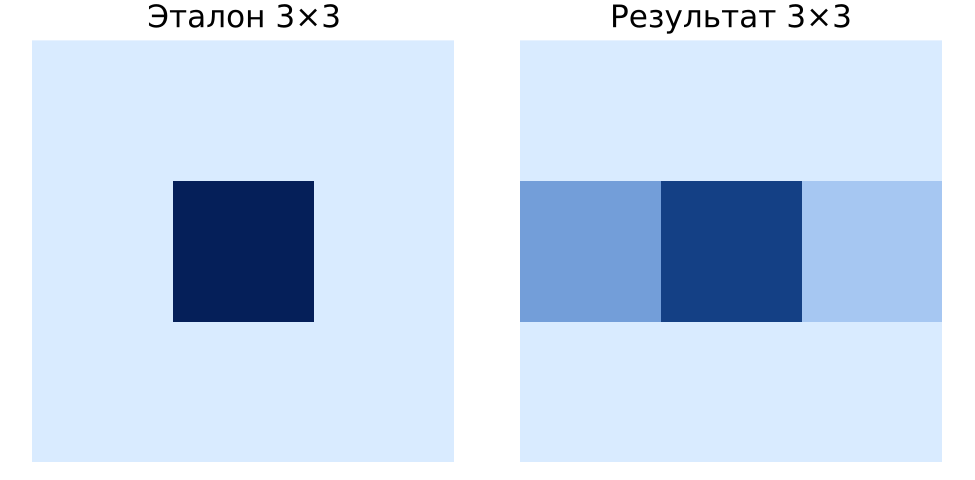

  GIF сохранён: board_3x3_evolution.gif
  Метрики...


[ Info: Saved animation to c:\programming\optimization-methods\lab18_geo\board_3x3_evolution.gif


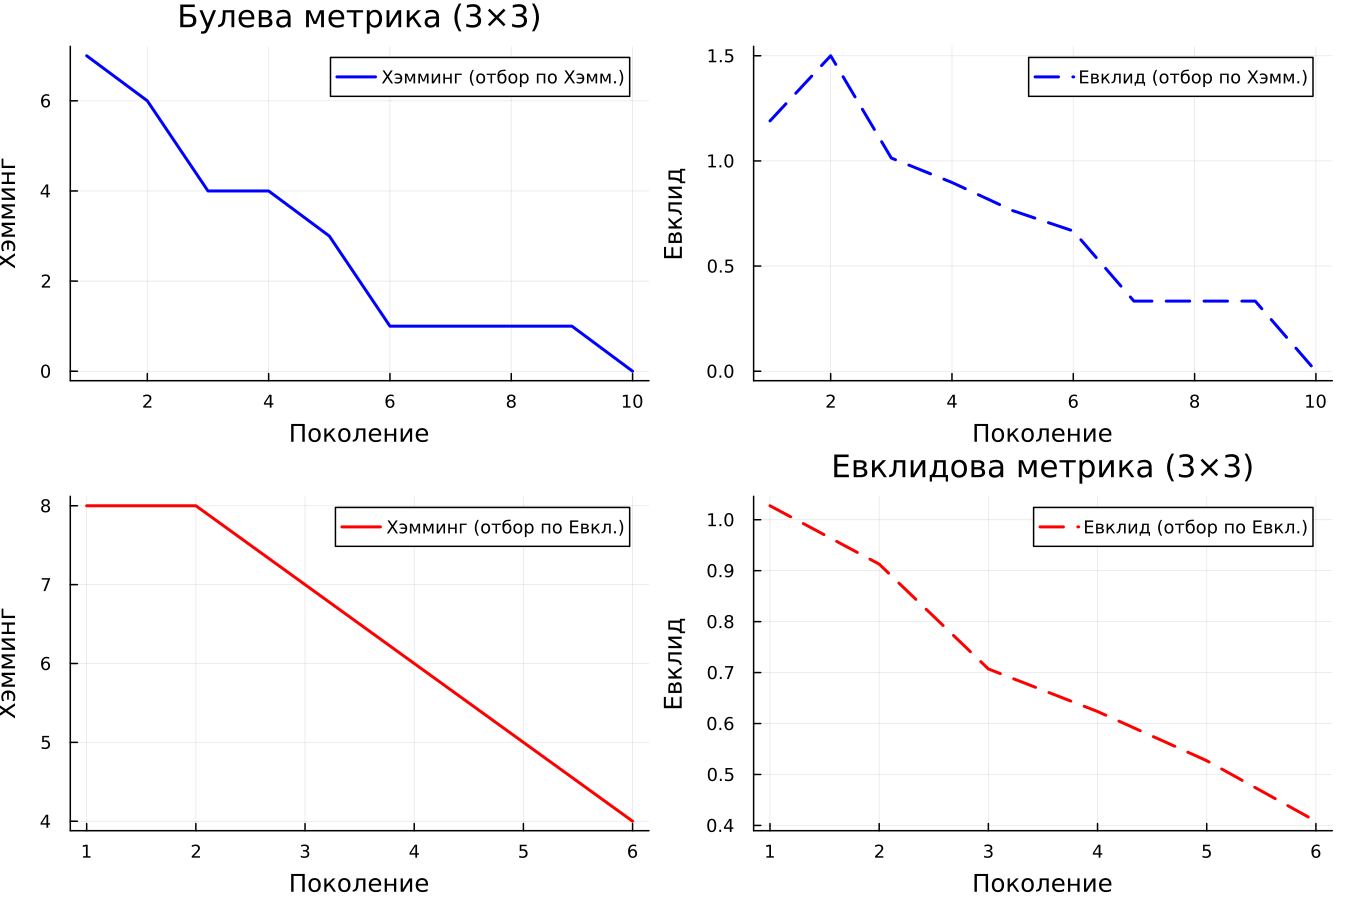

  Mutation rate...


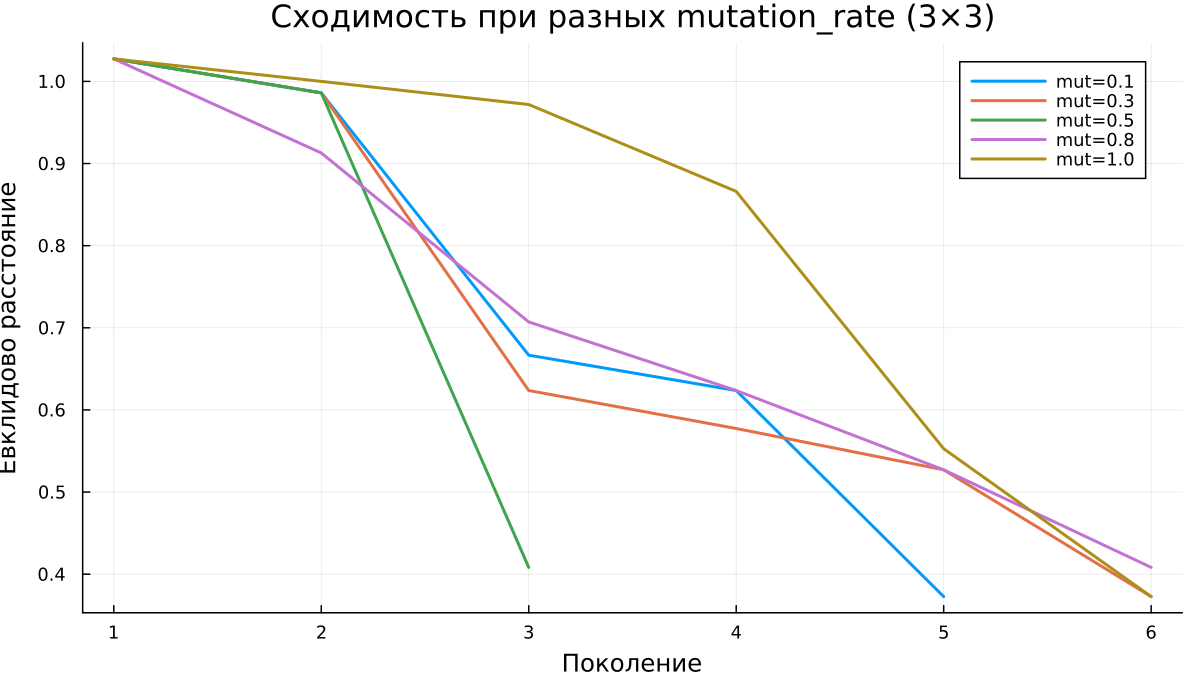

  Кроссинговер...


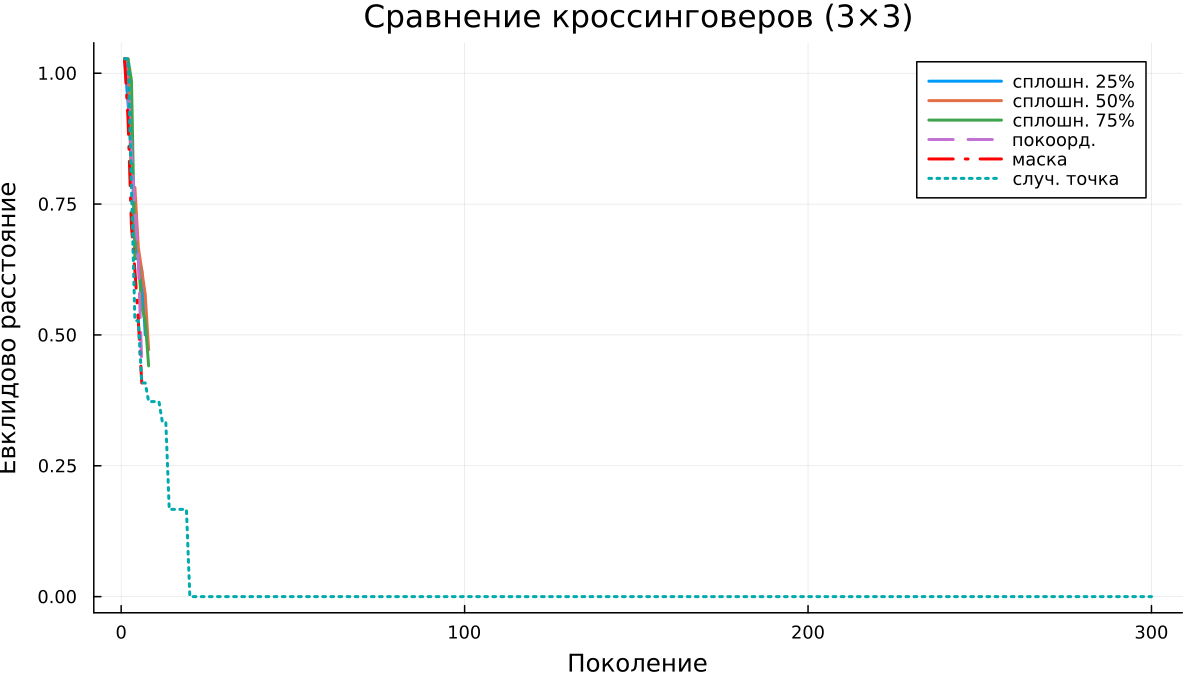

  Готово для 3×3

ДОСКА 5×5
  Поколение 1: Хэмминг=27, Евклид=2.198
  СОШЛОСЬ на поколении 18 (Евклид ≤ 0.5)


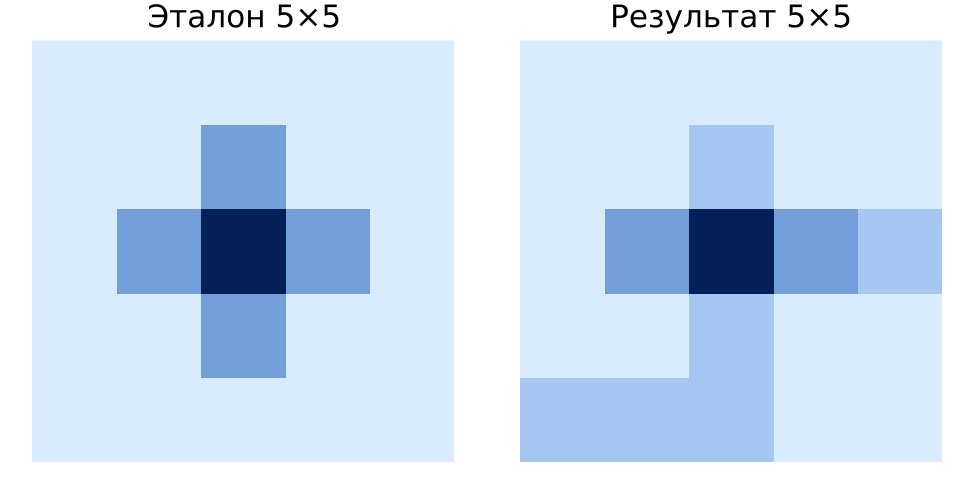

  GIF сохранён: board_5x5_evolution.gif
  Метрики...


[ Info: Saved animation to c:\programming\optimization-methods\lab18_geo\board_5x5_evolution.gif


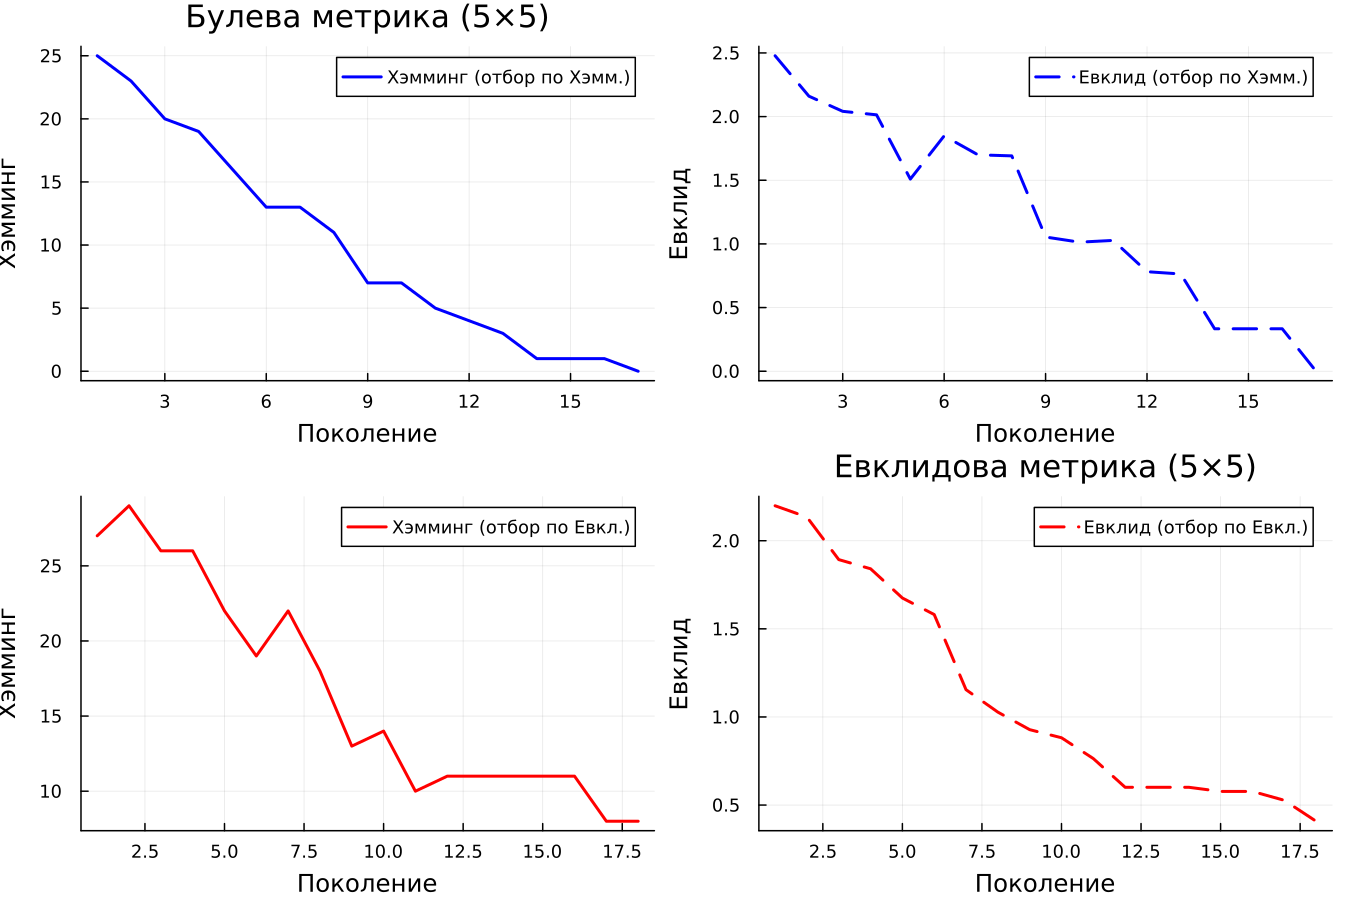

  Mutation rate...


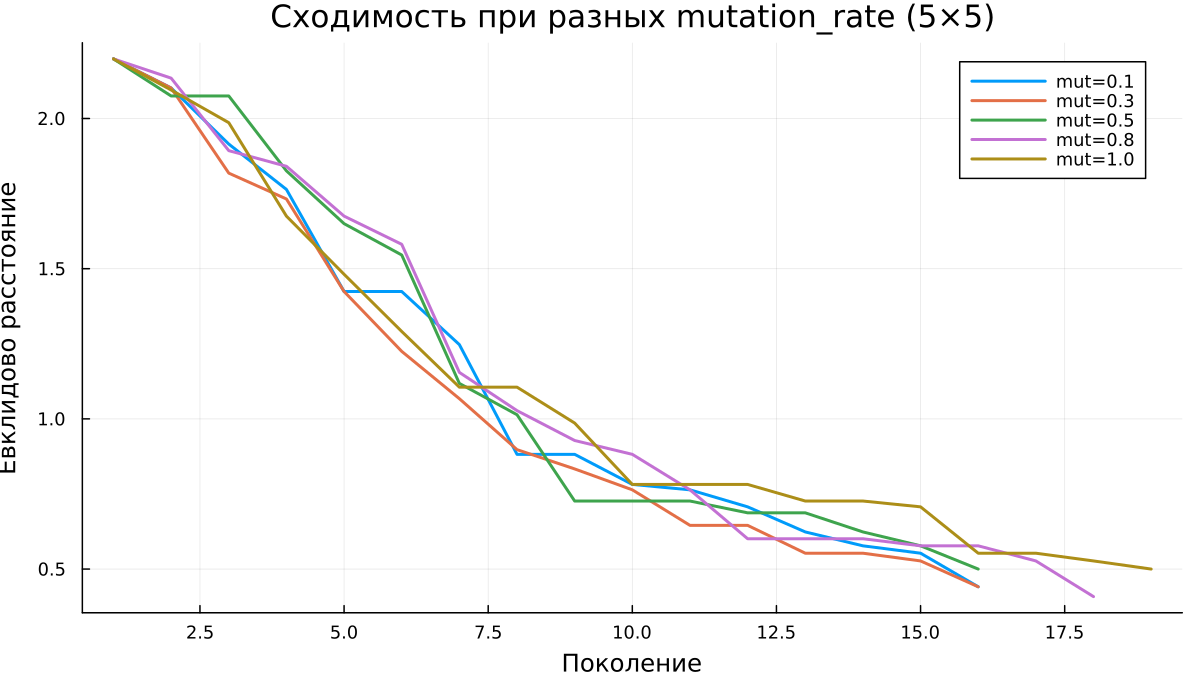

  Кроссинговер...


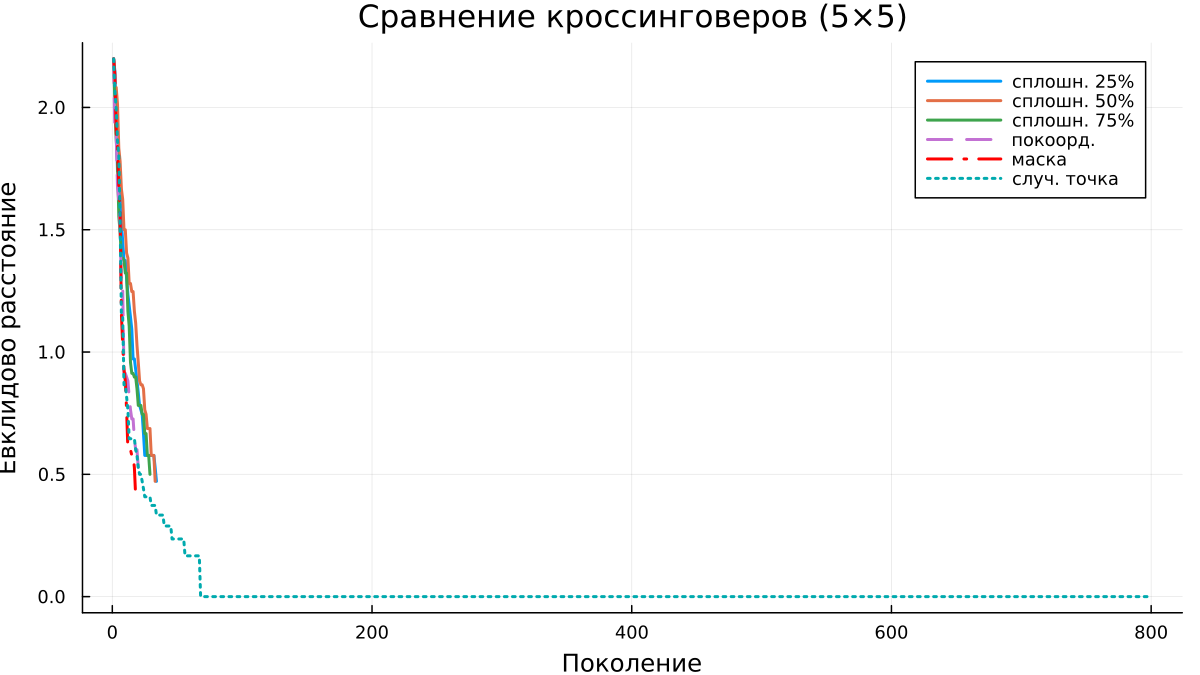

  Готово для 5×5

ДОСКА 9×9
  Поколение 1: Хэмминг=101, Евклид=4.317
  Поколение 21: Хэмминг=61, Евклид=1.481
  Поколение 41: Хэмминг=37, Евклид=0.898
  Поколение 61: Хэмминг=22, Евклид=0.577
  СОШЛОСЬ на поколении 74 (Евклид ≤ 0.5)


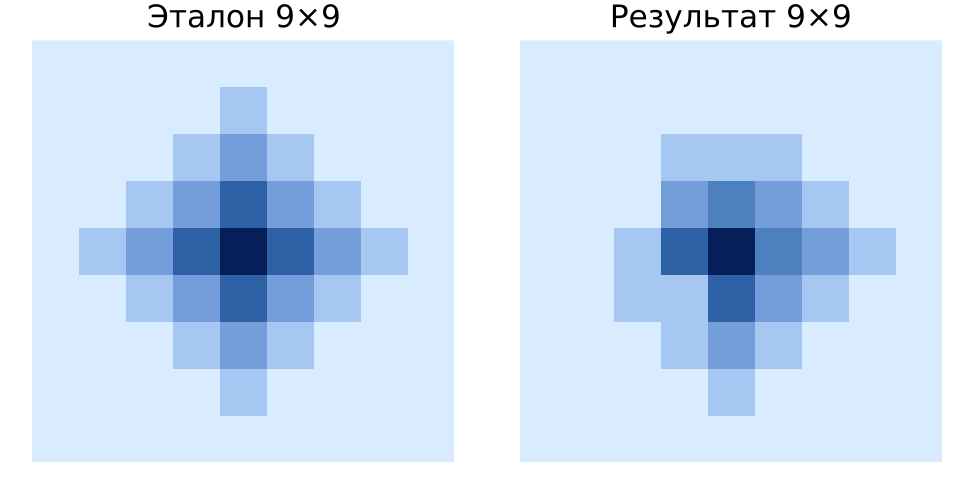

  GIF сохранён: board_9x9_evolution.gif
  Метрики...


[ Info: Saved animation to c:\programming\optimization-methods\lab18_geo\board_9x9_evolution.gif


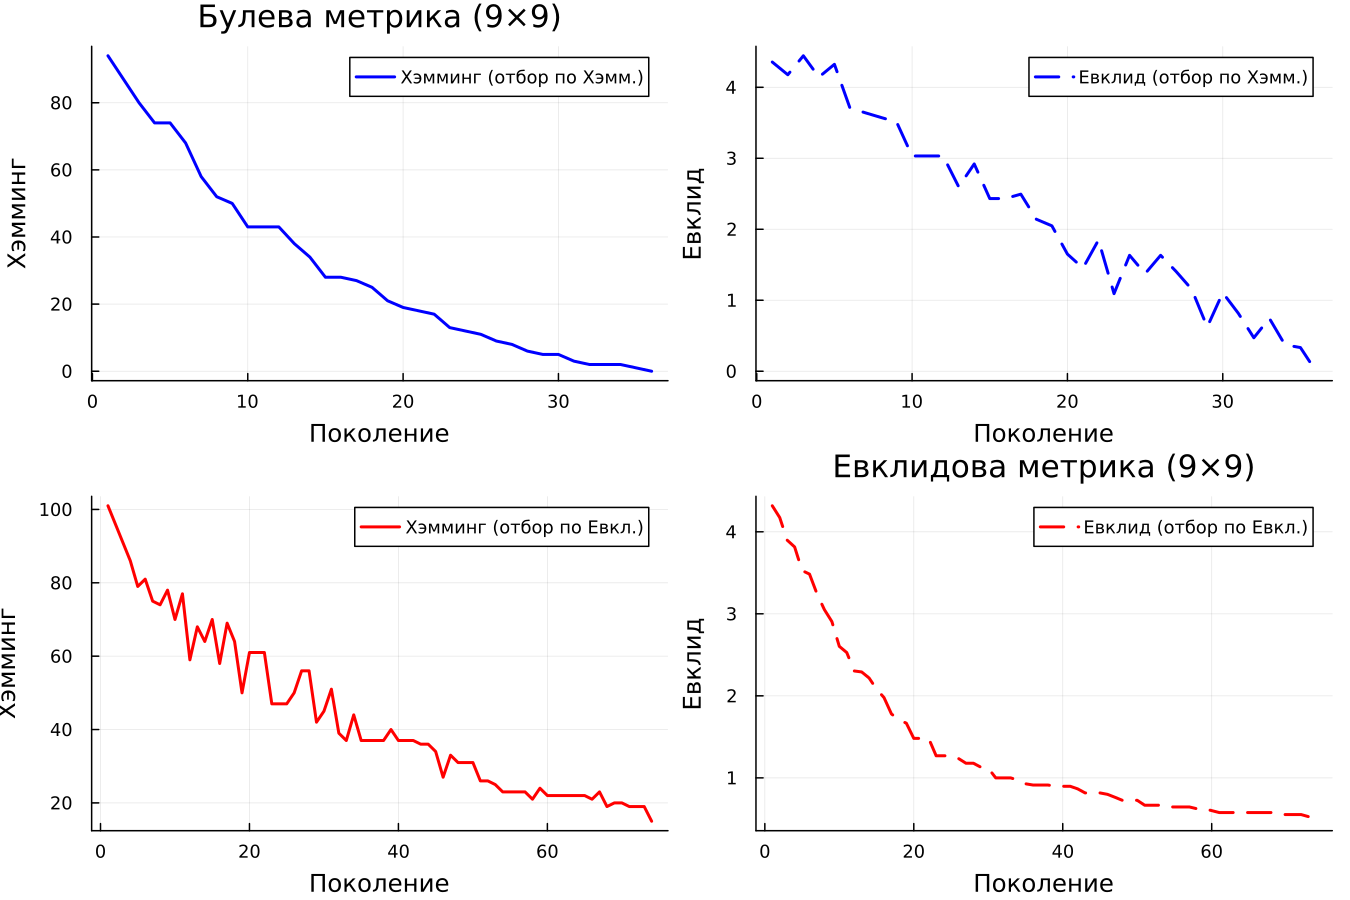

  Mutation rate...


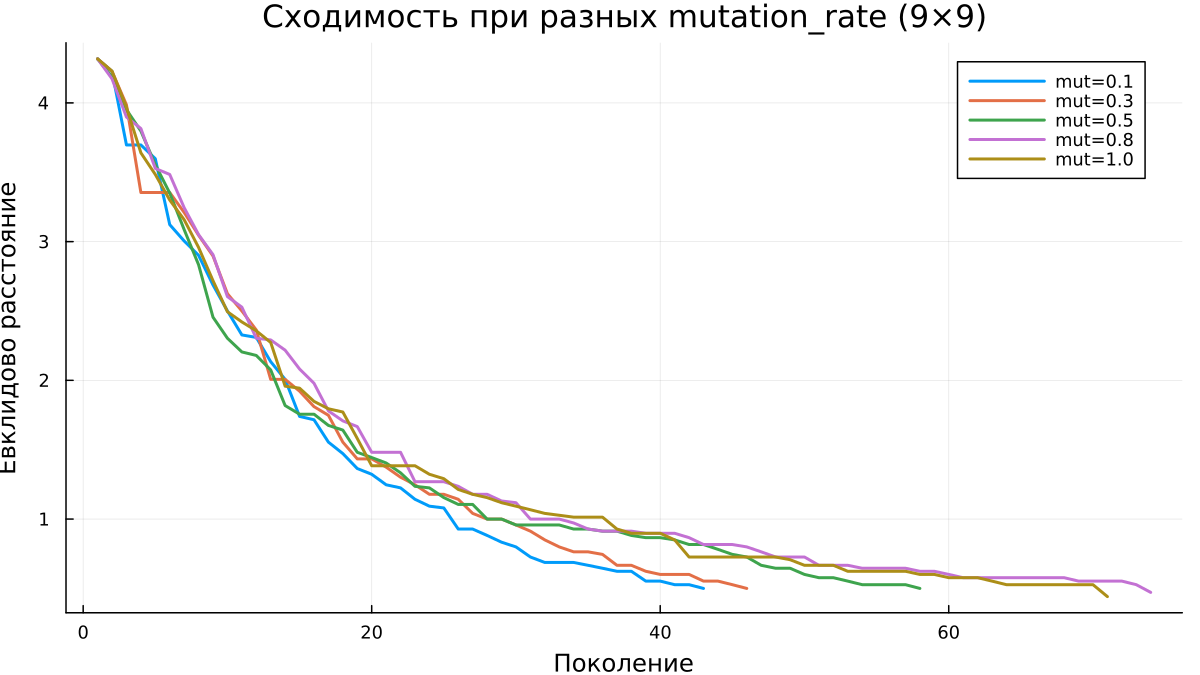

  Кроссинговер...


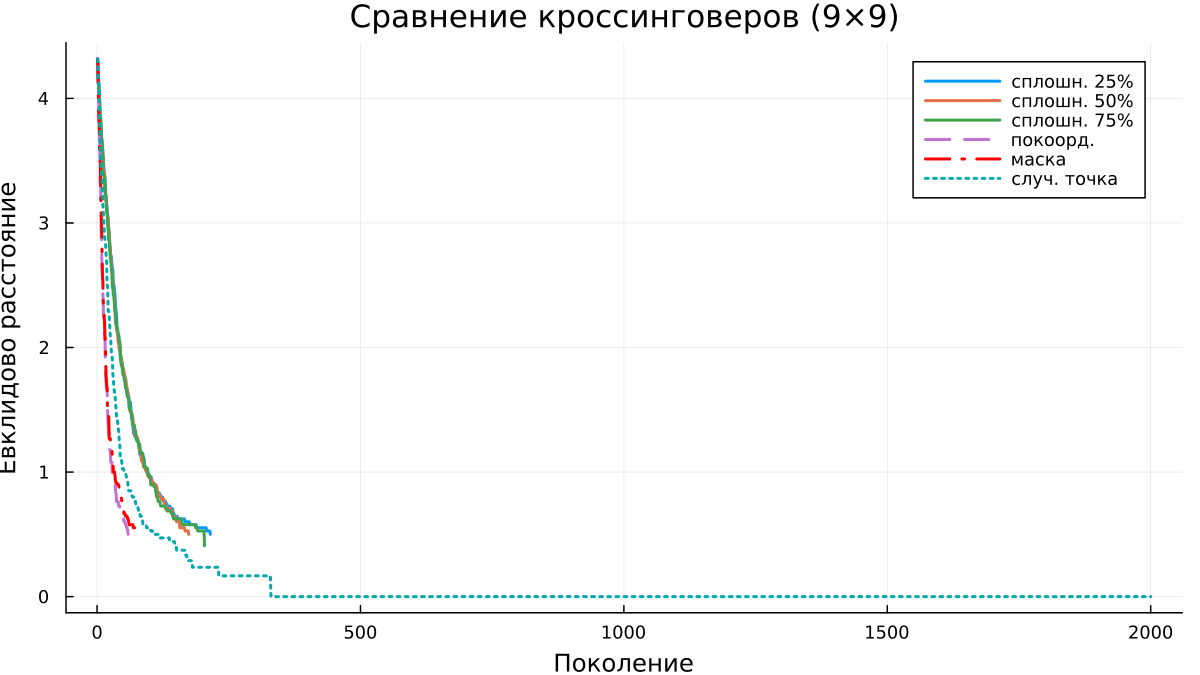

  Готово для 9×9

ДОСКА 21×21
  Поколение 1: Хэмминг=538, Евклид=10.872
  Поколение 21: Хэмминг=411, Евклид=7.365
  Поколение 41: Хэмминг=307, Евклид=4.391
  Поколение 61: Хэмминг=254, Евклид=2.863
  Поколение 81: Хэмминг=200, Евклид=2.205
  Поколение 101: Хэмминг=158, Евклид=1.787
  Поколение 121: Хэмминг=128, Евклид=1.472
  Поколение 141: Хэмминг=113, Евклид=1.312
  Поколение 161: Хэмминг=104, Евклид=1.213
  Поколение 181: Хэмминг=94, Евклид=1.118
  Поколение 201: Хэмминг=92, Евклид=1.08
  Поколение 221: Хэмминг=92, Евклид=1.027
  Поколение 241: Хэмминг=91, Евклид=1.027
  Поколение 261: Хэмминг=89, Евклид=1.014
  Поколение 281: Хэмминг=84, Евклид=1.0
  Поколение 301: Хэмминг=83, Евклид=0.972
  Поколение 321: Хэмминг=80, Евклид=0.943
  Поколение 341: Хэмминг=77, Евклид=0.928
  Поколение 361: Хэмминг=76, Евклид=0.913
  Поколение 381: Хэмминг=72, Евклид=0.898
  Поколение 401: Хэмминг=72, Евклид=0.882
  Поколение 421: Хэмминг=68, Евклид=0.85
  Поколение 441: Хэмминг=66, Евклид=0.85
  Пок

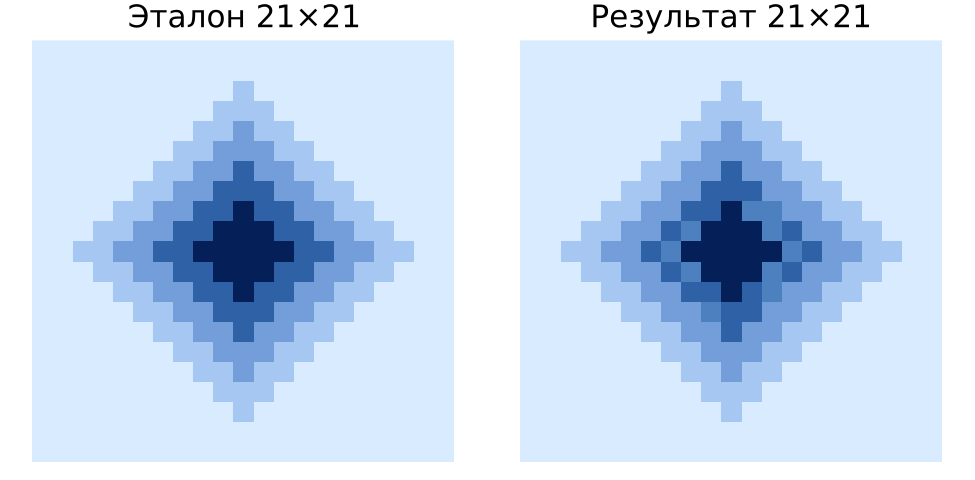

In [ ]:
using Plots, Random

# === КОНФИГУРАЦИЯ ===
const N_COLORS = 7
const N_BITS = 3
const POP_SIZE = 20
const MAX_GEN = 200
const EPS_BOOL = 0
const EPS_EUCL = 0.5
const MUTATION_RATE = 0.8
const CROSSOVER_PT_FRAC = 0.5
const SEED = 42

const OUTPUT_DIR = "lab18_geo"
const SAVE_GIF = true
const GIF_FPS = 4

# палитра
const COLOR_PALETTE = [
    RGB(0.85, 0.92, 1.0),
    RGB(0.65, 0.78, 0.95),
    RGB(0.45, 0.62, 0.85),
    RGB(0.30, 0.50, 0.75),
    RGB(0.18, 0.38, 0.65),
    RGB(0.08, 0.25, 0.52),
    RGB(0.02, 0.12, 0.35),
]

# === КОДИРОВАНИЕ / ДЕКОДИРОВАНИЕ ===

int_to_bits(x::Int, nb::Int) = digits(x, base=2, pad=nb) |> reverse
bits_to_int(bits::Vector{Int}) = sum(b * 2^(length(bits)-i) for (i,b) in enumerate(bits))

function encode_chromosome(colors::Vector{Int})
    bits = Int[]
    for c in colors
        append!(bits, int_to_bits(c, N_BITS))
    end
    return bits
end

function decode_chromosome(bits::Vector{Int})
    n = length(bits) ÷ N_BITS
    colors = Int[]
    for i in 1:n
        seg = bits[(i-1)*N_BITS+1 : i*N_BITS]
        val = bits_to_int(seg)
        push!(colors, clamp(val, 0, N_COLORS-1))
    end
    return colors
end

# === ГЕНЕТИЧЕСКИЕ ОПЕРАТОРЫ ===

function crossover_single(p1::Vector{Int}, p2::Vector{Int}, point::Int)
    c1 = vcat(p1[1:point], p2[point+1:end])
    c2 = vcat(p2[1:point], p1[point+1:end])
    return c1, c2
end

function crossover_coordinatewise(p1::Vector{Int}, p2::Vector{Int})
    n_genes = length(p1) ÷ N_BITS
    c1 = similar(p1)
    c2 = similar(p2)
    for g in 1:n_genes
        rng = (g-1)*N_BITS+1 : g*N_BITS
        if rand() < 0.5
            c1[rng] .= p1[rng]; c2[rng] .= p2[rng]
        else
            c1[rng] .= p2[rng]; c2[rng] .= p1[rng]
        end
    end
    return c1, c2
end

# случайная маска: для каждого бита независимо выбираем родителя
function crossover_mask(p1::Vector{Int}, p2::Vector{Int})
    mask = rand(Bool, length(p1))
    c1 = [mask[i] ? p1[i] : p2[i] for i in eachindex(p1)]
    c2 = [mask[i] ? p2[i] : p1[i] for i in eachindex(p1)]
    return c1, c2
end

function mutate!(bits::Vector{Int}, rate::Float64)
    # с вероятностью rate инвертируем один случайный бит
    if rand() < rate
        i = rand(1:length(bits))
        bits[i] = 1 - bits[i]
        # если ген вышел за N_COLORS — перегенерируем этот ген
        g = (i - 1) ÷ N_BITS + 1
        rng = (g-1)*N_BITS+1 : g*N_BITS
        if bits_to_int(bits[rng]) >= N_COLORS
            bits[rng] .= int_to_bits(rand(0:N_COLORS-1), N_BITS)
        end
    end
    return bits
end

# === МЕТРИКИ ===

hamming_dist(a::Vector{Int}, b::Vector{Int}) = sum(a .!= b)

function euclidean_dist(chrom::Vector{Int}, target_chrom::Vector{Int})
    c1 = decode_chromosome(chrom)
    c2 = decode_chromosome(target_chrom)
    # нормируем цвета в [0, 1]
    n1 = c1 ./ (N_COLORS - 1)
    n2 = c2 ./ (N_COLORS - 1)
    return sqrt(sum((n1 .- n2).^2))
end

# === ЭТАЛОН: КОНЦЕНТРИЧЕСКИЙ РОМБ ===

function generate_target(board_size::Int; seed=1)
    cx = (board_size + 1) / 2.0
    cy = (board_size + 1) / 2.0
    max_dist = cx - 1

    colors = Int[]
    for row in 1:board_size
        for col in 1:board_size
            d = abs(row - cx) + abs(col - cy)
            if max_dist < 1
                push!(colors, 6)
            else
                t = d / max_dist
                if t <= 0.2
                    push!(colors, 6)  # самый тёмный центр
                elseif t <= 0.4
                    push!(colors, 4)
                elseif t <= 0.6
                    push!(colors, 2)
                elseif t <= 0.8
                    push!(colors, 1)
                else
                    push!(colors, 0)  # самый светлый фон
                end
            end
        end
    end
    return colors
end

# === ВИЗУАЛИЗАЦИЯ ===

function plot_board(colors::Vector{Int}, board_size::Int; title_str="")
    mat = zeros(RGB{Float64}, board_size, board_size)
    for row in 1:board_size, col in 1:board_size
        idx = (row-1)*board_size + col
        c = clamp(colors[idx], 0, N_COLORS-1)
        mat[row, col] = COLOR_PALETTE[c+1]
    end
    mat_flip = mat[end:-1:1, :]
    return heatmap(mat_flip, aspect_ratio=:equal, axis=false, ticks=false,
        colorbar=false, title=title_str, size=(300, 300), border=:none)
end

function plot_frame(target_colors, best_colors, board_size, gen, best_hamming, best_eucl)
    p1 = plot_board(target_colors, board_size, title_str="Эталон")
    p2 = plot_board(best_colors, board_size,
        title_str="Поколение $gen\nХэмм=$best_hamming, Евкл=$(round(best_eucl, digits=2))")
    return plot(p1, p2, layout=(1,2), size=(650, 320), dpi=100)
end

# === ОСНОВНОЙ ГА ===

function run_ga(board_size::Int;
    pop_size=POP_SIZE, max_gen=MAX_GEN,
    mutation_rate=MUTATION_RATE,
    crossover_mode=:mask,
    crossover_pt_frac=CROSSOVER_PT_FRAC,
    metric=:euclidean,
    eps_val=EPS_EUCL,
    seed=SEED,
    make_frames=true,
    target_colors=nothing,
    verbose=false)

    Random.seed!(seed)
    n_cells = board_size * board_size
    chrom_len = n_cells * N_BITS
    crossover_pt = max(1, round(Int, chrom_len * crossover_pt_frac))

    if target_colors === nothing
        target_colors = generate_target(board_size)
    end
    target_chrom = encode_chromosome(target_colors)

    population = [encode_chromosome([rand(0:N_COLORS-1) for _ in 1:n_cells]) for _ in 1:pop_size]

    history_hamming = Float64[]
    history_eucl = Float64[]
    frames = []

    for gen in 1:max_gen
        if metric == :hamming
            dist = [hamming_dist(ind, target_chrom) for ind in population]
        else
            dist = [euclidean_dist(ind, target_chrom) for ind in population]
        end

        best_idx = argmin(dist)
        best_chrom = population[best_idx]
        best_val = dist[best_idx]

        bh = hamming_dist(best_chrom, target_chrom)
        be = euclidean_dist(best_chrom, target_chrom)
        push!(history_hamming, bh)
        push!(history_eucl, be)

        if verbose && (gen % 20 == 1 || gen == max_gen)
            println("  Поколение $gen: Хэмминг=$bh, Евклид=$(round(be, digits=3))")
        end

        if make_frames && (gen % max(1, max_gen ÷ 40) == 1 || gen == max_gen || gen <= 5)
            bc = decode_chromosome(best_chrom)
            push!(frames, plot_frame(target_colors, bc, board_size, gen, bh, round(be, digits=2)))
        end

        if metric == :hamming && best_val <= EPS_BOOL
            if verbose; println("  СОШЛОСЬ на поколении $gen (Хэмминг=0)"); end
            break
        elseif metric == :euclidean && best_val <= eps_val
            if verbose; println("  СОШЛОСЬ на поколении $gen (Евклид ≤ $eps_val)"); end
            break
        end

        # турнирная селекция
        new_pop = Vector{Vector{Int}}()
        for _ in 1:pop_size
            candidates = rand(1:pop_size, 3)
            winner = candidates[argmin(dist[candidates])]
            push!(new_pop, copy(population[winner]))
        end

        # кроссинговер
        offspring = Vector{Vector{Int}}()
        shuffled = randperm(pop_size)
        for i in 1:2:pop_size
            if i+1 > pop_size
                push!(offspring, copy(new_pop[shuffled[i]]))
                continue
            end
            p1 = new_pop[shuffled[i]]
            p2 = new_pop[shuffled[i+1]]
            if crossover_mode == :single
                c1, c2 = crossover_single(p1, p2, crossover_pt)
            elseif crossover_mode == :coord
                c1, c2 = crossover_coordinatewise(p1, p2)
            else
                c1, c2 = crossover_mask(p1, p2)
            end
            push!(offspring, c1)
            push!(offspring, c2)
        end

        for ind in offspring
            mutate!(ind, mutation_rate)
        end

        # элитизм
        offspring[end] = copy(best_chrom)
        population = offspring
    end

    best_colors = decode_chromosome(population[argmin(
        [metric == :hamming ? hamming_dist(ind, target_chrom) : euclidean_dist(ind, target_chrom) for ind in population]
    )])

    return best_colors, history_hamming, history_eucl, frames, target_colors
end

# === ГА со случайной точкой кроссинговера ===

function run_ga_random_crossover(board_size; pop_size=30, max_gen=200, target_colors=nothing, seed=SEED)
    Random.seed!(seed)
    n_cells = board_size * board_size
    chrom_len = n_cells * N_BITS

    if target_colors === nothing
        target_colors = generate_target(board_size)
    end
    target_chrom = encode_chromosome(target_colors)

    population = [encode_chromosome([rand(0:N_COLORS-1) for _ in 1:n_cells]) for _ in 1:pop_size]
    history_eucl = Float64[]

    for gen in 1:max_gen
        dist = [euclidean_dist(ind, target_chrom) for ind in population]
        best_idx = argmin(dist)
        best_chrom = population[best_idx]
        push!(history_eucl, euclidean_dist(best_chrom, target_chrom))

        new_pop = Vector{Vector{Int}}()
        for _ in 1:pop_size
            cands = rand(1:pop_size, 3)
            winner = cands[argmin(dist[cands])]
            push!(new_pop, copy(population[winner]))
        end

        offspring = Vector{Vector{Int}}()
        shuffled = randperm(pop_size)
        for i in 1:2:pop_size
            if i+1 > pop_size
                push!(offspring, copy(new_pop[shuffled[i]]))
                continue
            end
            cp = rand(1:chrom_len-1)
            c1, c2 = crossover_single(new_pop[shuffled[i]], new_pop[shuffled[i+1]], cp)
            push!(offspring, c1)
            push!(offspring, c2)
        end
        for ind in offspring; mutate!(ind, MUTATION_RATE); end
        offspring[end] = copy(best_chrom)
        population = offspring
    end
    return history_eucl
end

# === ЭКСПЕРИМЕНТЫ ===

function run_all()
    mkpath(OUTPUT_DIR)

    board_sizes = [3, 5, 9, 21]
    gen_limits = Dict(3 => 300, 5 => 800, 9 => 2000, 21 => 5000)
    pop_sizes  = Dict(3 => 50, 5 => 80, 9 => 150, 21 => 300)
    rates = [0.1, 0.3, 0.5, 0.8, 1.0]

    p_conv = plot(title="Сходимость (евклидова метрика) по размерам доски",
        xlabel="Поколение", ylabel="Евклидово расстояние",
        size=(800, 450), dpi=150, legend=:topright)

    for bs in board_sizes
        mg = gen_limits[bs]
        ps = pop_sizes[bs]
        target = generate_target(bs)

        println("\n" * "=" ^ 60)
        println("ДОСКА $(bs)×$(bs)")
        println("=" ^ 60)

        # основной запуск
        best_c, hh, he, frames, tc = run_ga(bs,
            pop_size=ps, max_gen=mg,
            metric=:euclidean, verbose=true, make_frames=true,
            target_colors=target)

        plot!(p_conv, 1:length(he), he, label="$(bs)×$(bs)", lw=2)

        p_final = plot(
            plot_board(tc, bs, title_str="Эталон $(bs)×$(bs)"),
            plot_board(best_c, bs, title_str="Результат $(bs)×$(bs)"),
            layout=(1,2), size=(650, 320), dpi=150)
        savefig(p_final, joinpath(OUTPUT_DIR, "board_$(bs)x$(bs)_final.png"))
        display(p_final)

        if SAVE_GIF && length(frames) > 0
            anim = Animation()
            for fr in frames; frame(anim, fr); end
            gif(anim, joinpath(OUTPUT_DIR, "board_$(bs)x$(bs)_evolution.gif"), fps=GIF_FPS)
            println("  GIF сохранён: board_$(bs)x$(bs)_evolution.gif")
        end

        # булева vs евклидова метрика
        println("  Метрики...")
        _, hh_bool, he_bool, _, _ = run_ga(bs, pop_size=ps, max_gen=mg, metric=:hamming,
            target_colors=target, make_frames=false)
        _, hh_eucl, he_eucl, _, _ = run_ga(bs, pop_size=ps, max_gen=mg, metric=:euclidean,
            target_colors=target, make_frames=false)

        p_metric = plot(
            plot(1:length(hh_bool), hh_bool, label="Хэмминг (отбор по Хэмм.)", lw=2, color=:blue,
                xlabel="Поколение", ylabel="Хэмминг", title="Булева метрика ($(bs)×$(bs))"),
            plot(1:length(he_bool), he_bool, label="Евклид (отбор по Хэмм.)", lw=2, color=:blue, ls=:dash,
                xlabel="Поколение", ylabel="Евклид"),
            plot(1:length(hh_eucl), hh_eucl, label="Хэмминг (отбор по Евкл.)", lw=2, color=:red,
                xlabel="Поколение", ylabel="Хэмминг"),
            plot(1:length(he_eucl), he_eucl, label="Евклид (отбор по Евкл.)", lw=2, color=:red, ls=:dash,
                xlabel="Поколение", ylabel="Евклид", title="Евклидова метрика ($(bs)×$(bs))"),
            layout=(2,2), size=(900, 600), dpi=150)
        savefig(p_metric, joinpath(OUTPUT_DIR, "metric_comparison_$(bs)x$(bs).png"))
        display(p_metric)

        # разные mutation_rate
        println("  Mutation rate...")
        p_mut = plot(title="Сходимость при разных mutation_rate ($(bs)×$(bs))",
            xlabel="Поколение", ylabel="Евклидово расстояние",
            size=(800, 450), dpi=150, legend=:topright)
        for mr in rates
            _, _, he_mr, _, _ = run_ga(bs, pop_size=ps, max_gen=mg, mutation_rate=mr,
                target_colors=target, make_frames=false)
            plot!(p_mut, 1:length(he_mr), he_mr, label="mut=$(mr)", lw=2)
        end
        savefig(p_mut, joinpath(OUTPUT_DIR, "mutation_comparison_$(bs)x$(bs).png"))
        display(p_mut)

        # сравнение кроссинговеров: сплошной, покоординатный, маска
        println("  Кроссинговер...")
        p_cross = plot(title="Сравнение кроссинговеров ($(bs)×$(bs))",
            xlabel="Поколение", ylabel="Евклидово расстояние",
            size=(800, 450), dpi=150, legend=:topright)
        for frac in [0.25, 0.5, 0.75]
            _, _, he_f, _, _ = run_ga(bs, pop_size=ps, max_gen=mg, crossover_mode=:single,
                crossover_pt_frac=frac, target_colors=target, make_frames=false)
            plot!(p_cross, 1:length(he_f), he_f, label="сплошн. $(Int(frac*100))%", lw=2)
        end
        _, _, he_coord, _, _ = run_ga(bs, pop_size=ps, max_gen=mg, crossover_mode=:coord,
            target_colors=target, make_frames=false)
        plot!(p_cross, 1:length(he_coord), he_coord, label="покоорд.", lw=2, ls=:dash)
        _, _, he_mask, _, _ = run_ga(bs, pop_size=ps, max_gen=mg, crossover_mode=:mask,
            target_colors=target, make_frames=false)
        plot!(p_cross, 1:length(he_mask), he_mask, label="маска", lw=2, ls=:dashdot, color=:red)
        he_rand = run_ga_random_crossover(bs, pop_size=ps, max_gen=mg, target_colors=target)
        plot!(p_cross, 1:length(he_rand), he_rand, label="случ. точка", lw=2, ls=:dot)
        savefig(p_cross, joinpath(OUTPUT_DIR, "crossover_comparison_$(bs)x$(bs).png"))
        display(p_cross)

        println("  Готово для $(bs)×$(bs)")
    end

    savefig(p_conv, joinpath(OUTPUT_DIR, "convergence_by_size.png"))
    display(p_conv)

    println("\n" * "=" ^ 60)
    println("ВСЕ РЕЗУЛЬТАТЫ В: $OUTPUT_DIR/")
    println("=" ^ 60)
    for f in sort(readdir(OUTPUT_DIR))
        println("  $f")
    end
end

run_all()